In [12]:
import os
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# -----------------------------
# Configuration / Calibration
# -----------------------------
# Map 263A current ranges to calibrated kI (A/V). Edit as needed.
CAL_KI = {
    "10uA": 1.0e-05,  # calibrated (A/V)
    "1uA":  1.0e-6,
    "100uA": 1.0e-4,
    "1mA":   1.0e-3,
    "10mA":  1.0e-2,
    "100mA": 1.0e-1,
}

def pick_kI(current_range: str | None, kI_override: float | None):
    """
    Choose kI (A/V) based on current_range key in CAL_KI or direct override.
    """
    if kI_override is not None:
        return float(kI_override), "override"
    if current_range is None:
        raise ValueError("Please provide current_range (e.g., '10uA') or kI_override.")
    if current_range not in CAL_KI or CAL_KI[current_range] in (None, float("nan")):
        raise ValueError(
            f"No calibrated kI for range='{current_range}'. "
            f"Add it to CAL_KI or pass kI_override."
        )
    return float(CAL_KI[current_range]), current_range

In [14]:
# -----------------------------
# Parsing Moku FRA CSV
# -----------------------------
def load_moku_csv(csv_path: str) -> pd.DataFrame:
    """
    Robustly load a Moku FRA CSV (skips comment lines '%').
    Returns a DataFrame with columns:
      Frequency_Hz, Ch1_Mag_dB, Ch1_Phase_deg,
      Ch2_Mag_dB, Ch2_Phase_deg,
      Math_Mag_dB, Math_Phase_deg
    If Math columns are not present (all-NaN), they remain NaN and we
    compute the ratio from Ch1/Ch2.
    """
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
        data_lines = [
            ln for ln in f
            if not ln.strip().startswith("%") and ln.strip() != ""
        ]

    names7 = [
        "Frequency_Hz",
        "Ch1_Mag_dB", "Ch1_Phase_deg",
        "Ch2_Mag_dB", "Ch2_Phase_deg",
        "Math_Mag_dB", "Math_Phase_deg",
    ]
    try:
        df = pd.read_csv(StringIO("".join(data_lines)),
                         header=None, names=names7)
    except Exception:
        # Fallback: let pandas infer structure
        df = pd.read_csv(StringIO("".join(data_lines)))
        if df.shape[1] >= 7:
            df.columns = names7 + [f"Extra_{i}" for i in range(df.shape[1]-7)]
        else:
            raise
    return df


# -----------------------------
# Impedance computation
# -----------------------------
def db_to_linear_mag(dB):
    """20*log10(V) -> linear magnitude."""
    return 10.0 ** (np.asarray(dB) / 20.0)

def compute_impedance(df: pd.DataFrame, kI: float, invert_if_needed: bool = True):
    """
    Compute complex impedance Z from Moku FRA export using calibrated kI.
    Returns frequency array, complex Z, and a flag indicating if inversion was applied.
    """
    freq = df["Frequency_Hz"].to_numpy(dtype=float)

    # use data with a specified frequency range
    freq_min = 800  # Hz
    freq_max = 10000.0  # Hz
    valid = (freq >= freq_min) & (freq <= freq_max)
    freq = freq[valid]
    df = df[valid].reset_index(drop=True) 

    # Prefer Math ratio if present, else compute from Ch1/Ch2
    if not df["Math_Mag_dB"].isna().all() and not df["Math_Phase_deg"].isna().all():
        R_mag = db_to_linear_mag(df["Math_Mag_dB"].to_numpy(dtype=float))
        R_ph = np.deg2rad(df["Math_Phase_deg"].to_numpy(dtype=float))
    else:
        R_mag = db_to_linear_mag(
            df["Ch1_Mag_dB"].to_numpy(dtype=float)
            - df["Ch2_Mag_dB"].to_numpy(dtype=float)
        )
        R_ph = np.deg2rad(
            df["Ch1_Phase_deg"].to_numpy(dtype=float)
            - df["Ch2_Phase_deg"].to_numpy(dtype=float)
        )

    R = R_mag * (np.cos(R_ph) + 1j * np.sin(R_ph))
    Z = (1.0 / kI) * R

    inverted = False
    if invert_if_needed:
        # Use a mid-band region if available to decide sign
        mid = (freq > 1.0) & (freq < 1000.0)
        if np.any(mid):
            if np.nanmedian(np.real(Z[mid])) < 0:
                Z = -Z
                inverted = True

    return freq, Z, inverted

In [15]:
# -----------------------------
# Multi-file plotting
# -----------------------------
def multi_plot_moku_fra(csv_paths, current_range: str | None = None,
                        kI_override: float | None = None,
                        save_plots: bool = True,
                        output_dir: str = "output"):
    """
    Process multiple Moku FRA CSV files and plot their Nyquist and Bode
    diagrams on shared axes.

    Parameters
    ----------
    csv_paths : list[str]
        List of CSV file paths.
    current_range : str or None
        Name in CAL_KI (e.g. "10uA"). Ignored if kI_override is given.
    kI_override : float or None
        Direct kI in A/V. If set, used for all files.
    save_plots : bool
        If True, saves PNGs to output_dir.
    output_dir : str
        Directory where plots are saved (created if missing).

    Returns
    -------
    results : list[dict]
        List with one dict per file containing:
        {"file": path, "freq": freq, "Z": Z, "inverted": bool, "kI": kI}
    """
    if isinstance(csv_paths, str):
        csv_paths = [csv_paths]

    if not csv_paths:
        raise ValueError("csv_paths is empty; provide at least one CSV path.")

    kI, how = pick_kI(current_range, kI_override)

    # Process each file
    results = []
    for path in csv_paths:
        df = load_moku_csv(path)
        freq, Z, inverted = compute_impedance(df, kI=kI, invert_if_needed=True)
        results.append({
            "file": path,
            "freq": freq,
            "Z": Z,
            "inverted": inverted,
            "kI": kI,
            "kI_source": how,
        })

    # ------------- Nyquist (combined) -------------
    plt.figure()
    for res in results:
        base = os.path.basename(res["file"])
        Z = res["Z"]
        plt.plot(np.real(Z), -np.imag(Z), '.', markersize=3, label=base)
    plt.xlabel("Re(Z) [Ω]")
    plt.ylabel("-Im(Z) [Ω]")
    plt.title("Nyquist (multi-file)")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()

    # ------------- Bode magnitude (combined) -------------
    plt.figure()
    for res in results:
        base = os.path.basename(res["file"])
        freq = res["freq"]
        Z = res["Z"]
        plt.semilogx(freq, np.abs(Z), label=base)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("|Z| [Ω]")
    plt.title("Bode magnitude (multi-file)")
    plt.grid(True)
    plt.legend()

    # ------------- Bode phase (combined) -------------
    plt.figure()
    for res in results:
        base = os.path.basename(res["file"])
        freq = res["freq"]
        Z = res["Z"]
        plt.semilogx(freq, np.rad2deg(np.angle(Z)), label=base)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Phase [deg]")
    plt.title("Bode phase (multi-file)")
    plt.grid(True)
    plt.legend()

    # Save plots if requested
    if save_plots:
        os.makedirs(output_dir, exist_ok=True)
        # Use a generic base name derived from the first file
        base0 = os.path.splitext(os.path.basename(csv_paths[0]))[0]
        figs = plt.get_fignums()
        for i, fig_num in enumerate(figs, start=1):
            plt.figure(fig_num)
            out_path = os.path.join(output_dir, f"{base0}_multi_plot{i}.png")
            plt.savefig(out_path, dpi=150)

    plt.show()
    return results

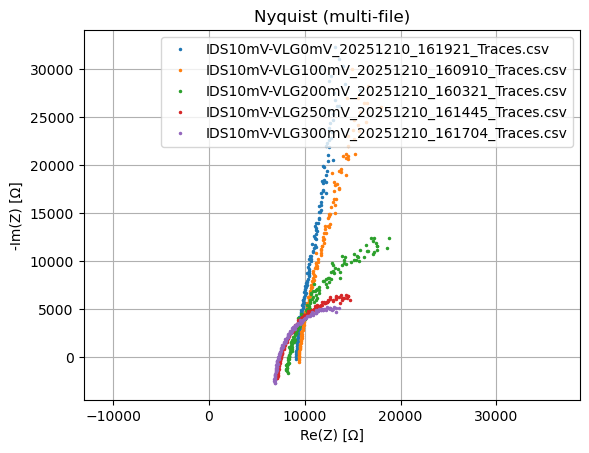

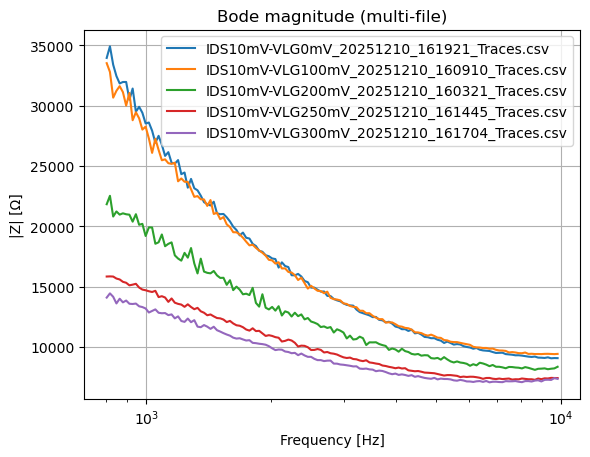

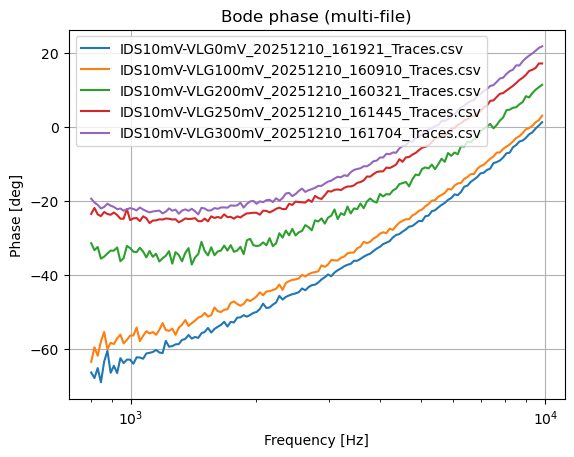

Processed files:
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG0mV_20251210_161921_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG100mV_20251210_160910_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG200mV_20251210_160321_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG250mV_20251210_161445_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG300mV_20251210_161704_Traces.csv: inv

In [16]:
files = [
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG0mV_20251210_161921_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG100mV_20251210_160910_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG200mV_20251210_160321_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG250mV_20251210_161445_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG300mV_20251210_161704_Traces.csv",
]
results = multi_plot_moku_fra(files, current_range="10uA", kI_override=None)
results
print("Processed files:")
for r in results:
    print(f"  {r['file']}: inverted={r['inverted']}, kI={r['kI']} A/V (source={r['kI_source']})")

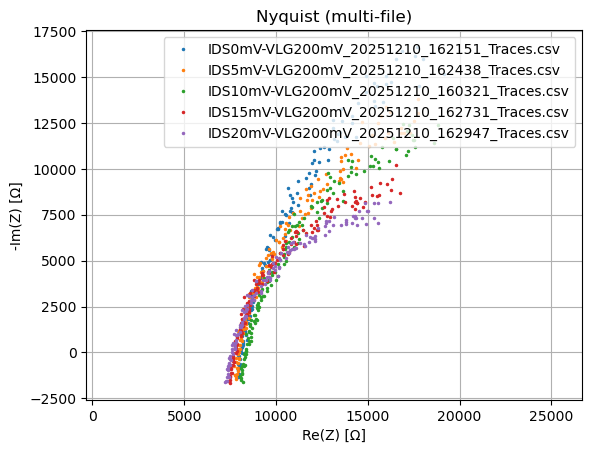

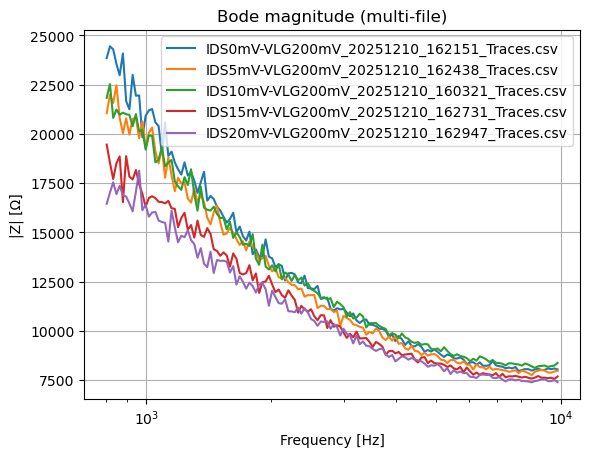

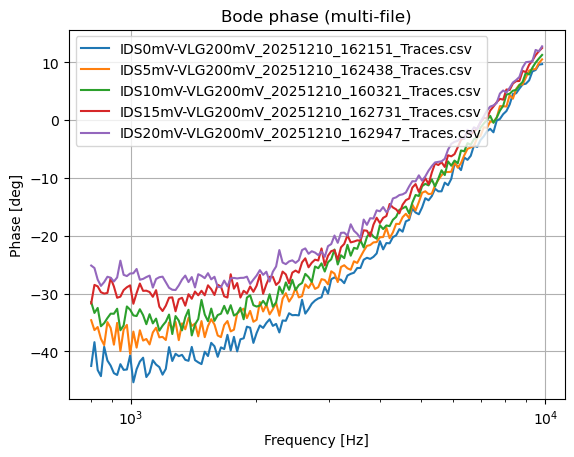

Processed files:
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS0mV-VLG200mV_20251210_162151_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS5mV-VLG200mV_20251210_162438_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG200mV_20251210_160321_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS15mV-VLG200mV_20251210_162731_Traces.csv: inverted=False, kI=1e-05 A/V (source=10uA)
  C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS20mV-VLG200mV_20251210_162947_Traces.csv: inv

In [17]:
files = [
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS0mV-VLG200mV_20251210_162151_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS5mV-VLG200mV_20251210_162438_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS10mV-VLG200mV_20251210_160321_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS15mV-VLG200mV_20251210_162731_Traces.csv",
    r"C:\Users\Lucy\OneDrive - University of Toronto\Grad\CAN\experimental results\raw data\Moku go\FRA\20251210\0409Cd7\IDS20mV-VLG200mV_20251210_162947_Traces.csv",
]
results = multi_plot_moku_fra(files, current_range="10uA", kI_override=None)
results
print("Processed files:")
for r in results:
    print(f"  {r['file']}: inverted={r['inverted']}, kI={r['kI']} A/V (source={r['kI_source']})")